# Notebook 06 — Error-Mode Analysis, Augmentation Sweep, Learning Curves, Dual-View CNN
Extends `05_predictions_and_diagnostics.ipynb` with four core (not supplementary) additions:
1. **Astrophysical error-mode analysis** — using autovetter vote fractions (`av_vf_ntp`, `av_vf_afp`) and the odd-even-depth statistic (`tce_bin_oedp_stat`) already present in `balanced_tce.csv` but unused so far, to see *what kind* of false positive each model struggles with, not just how many.
2. **Augmentation sweep** — five noise levels instead of one, turning the single-point ablation into an actual curve.
3. **Learning curves** — RF_main and CNN_1D trained on 10/25/50/75/100% of the training set, to characterize how each model degrades with less data.
4. **Dual-view (local+global) CNN + small ensemble + cosine LR schedule** — a architecturally-motivated attempt to close some of the RF/CNN gap, following the local/global view design of Shallue & Vanderburg (2018), approximated here by cropping our existing 200-point folded array rather than re-deriving a finer-resolution local view from raw flux (documented as a simplification below).

Everything reuses the same seeds (42), same row set, same train/val/test split as `03`–`05`.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, brier_score_loss)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

DRIVE_ROOT = '/content/drive/MyDrive/SADA'
CSV_PATH   = os.path.join(DRIVE_ROOT, 'balanced_tce.csv')
NPY_DIR    = os.path.join(DRIVE_ROOT, 'processed')
FIG_DIR    = os.path.join(DRIVE_ROOT, 'figures')
RES_DIR    = os.path.join(DRIVE_ROOT, 'results')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)


Mounted at /content/drive
Device: cuda


## 1. Rebuild the exact same row set + split (identical to 03/04/05)

In [5]:
balanced = pd.read_csv(CSV_PATH)

npy_files = [f for f in os.listdir(NPY_DIR) if f.endswith('.npy') and f != 'failed_kepids.npy']
pattern = re.compile(r'^(\d+)_(\d+)_(PC|FP)\.npy$')
records = []
for fname in npy_files:
    m = pattern.match(fname)
    if not m:
        continue
    kepid, plnt_num, label_str = m.groups()
    records.append({'kepid': int(kepid), 'tce_plnt_num': int(plnt_num),
                     'label': 1 if label_str == 'PC' else 0,
                     'npy_path': os.path.join(NPY_DIR, fname)})
npy_index = pd.DataFrame(records)

data = pd.merge(npy_index, balanced, on=['kepid', 'tce_plnt_num'], how='inner')
data = data.dropna(subset=['tce_period','tce_duration','tce_depth','tce_model_snr']).reset_index(drop=True)
print(f"Row set: {len(data)}")

def flux_shape_features(flux):
    flux = np.asarray(flux, dtype=float)
    n = len(flux)
    mean, std = flux.mean(), flux.std()
    minimum, maximum = flux.min(), flux.max()
    lo, hi = n // 3, 2 * n // 3
    in_transit = flux[lo:hi]
    out_transit = np.concatenate([flux[:lo], flux[hi:]])
    depth_est = out_transit.mean() - in_transit.min()
    in_std = in_transit.std()
    out_std = out_transit.std() if len(out_transit) else 0.0
    if std > 0:
        skew = ((flux - mean) ** 3).mean() / (std ** 3)
        kurt = ((flux - mean) ** 4).mean() / (std ** 4) - 3
    else:
        skew, kurt = 0.0, 0.0
    return {'flux_mean': mean, 'flux_std': std, 'flux_min': minimum, 'flux_max': maximum,
            'flux_depth_est': depth_est, 'flux_in_transit_std': in_std,
            'flux_out_transit_std': out_std, 'flux_skew': skew, 'flux_kurtosis': kurt}

flux_matrix = []
feature_rows = []
for path in data['npy_path']:
    flux = np.load(path).astype(np.float32)
    flux_matrix.append(flux)
    feature_rows.append(flux_shape_features(flux))
flux_matrix = np.stack(flux_matrix)
flux_feats = pd.DataFrame(feature_rows)
data = pd.concat([data.reset_index(drop=True), flux_feats], axis=1)
labels_all = data['label'].values.astype(np.float32)

BLS_FEATURES = ['tce_period', 'tce_duration', 'tce_depth', 'tce_model_snr']
FLUX_FEATURES = ['flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flux_depth_est',
                 'flux_in_transit_std', 'flux_out_transit_std', 'flux_skew', 'flux_kurtosis']
RF_FEATURES = BLS_FEATURES + FLUX_FEATURES

y = data['label'].values
idx_train, idx_temp = train_test_split(data.index, test_size=0.30, random_state=SEED, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED, stratify=y[idx_temp])
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

train_df, val_df, test_df = data.loc[idx_train], data.loc[idx_val], data.loc[idx_test]
y_test = test_df['label'].values


Row set: 4515
Train: 3160 | Val: 677 | Test: 678


## 2. Astrophysical error-mode analysis

`balanced_tce.csv` carries columns from a separate NASA autovetter run and the DR25 pipeline's own diagnostics that we have not used as model inputs, only as **post-hoc error labels**:
- `av_vf_ntp` — autovetter vote fraction for "not transit-like"
- `av_vf_afp` — autovetter vote fraction for "astrophysical false positive" (e.g. eclipsing binary, background contamination)
- `tce_bin_oedp_stat` — odd/even transit depth comparison statistic; a large magnitude is the classic eclipsing-binary signature (real planets should show equal odd/even transit depths)

We bucket each **false-positive** test example into a heuristic category using these three signals (whichever is most extreme, by tertile among test-set FPs), then compare each model's error rate within each bucket. This is a heuristic categorization from continuous diagnostics, not the official categorical Robovetter minor flags (which are not present in this CSV) — we report it as such.


In [6]:
def fit_eval_tabular(name, model, feature_cols, scale=False):
    X_train = train_df[feature_cols].values
    X_test  = test_df[feature_cols].values
    y_train = train_df['label'].values
    if scale:
        scaler = StandardScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs > 0.5).astype(int)
    print(f"{name}: acc={accuracy_score(y_test, preds):.4f} f1={f1_score(y_test, preds):.4f} auc={roc_auc_score(y_test, probs):.4f}")
    return model, probs, preds

rf_main, rf_probs, rf_preds = fit_eval_tabular('RF_main', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), RF_FEATURES)

class FluxDataset(Dataset):
    def __init__(self, indices, augment=False, alpha=0.3):
        self.indices = indices; self.augment = augment; self.alpha = alpha
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        flux = flux_matrix[idx].copy()
        if self.augment:
            noise_std = self.alpha * flux.std()
            flux = flux + np.random.normal(0, noise_std, size=flux.shape).astype(np.float32)
        return torch.tensor(flux).unsqueeze(0), torch.tensor(labels_all[idx])

class Conv1DClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv1d(1, 8, 5, padding=2), nn.BatchNorm1d(8), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.block2 = nn.Sequential(nn.Conv1d(8, 16, 5, padding=2), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.block3 = nn.Sequential(nn.Conv1d(16, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)

def train_cnn(model, train_idx, val_idx, augment_train=False, alpha=0.3, n_epochs=60, patience=8,
              lr=1e-3, weight_decay=1e-4, use_cosine=False, seed=SEED):
    torch.manual_seed(seed)
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs) if use_cosine else None

    train_loader = DataLoader(FluxDataset(train_idx, augment=augment_train, alpha=alpha), batch_size=64, shuffle=True)
    val_loader = DataLoader(FluxDataset(val_idx, augment=False), batch_size=64, shuffle=False)

    best_val_loss, best_state, no_improve = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            train_losses.append(loss.item())
        if scheduler is not None:
            scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
        val_loss = np.mean(val_losses)
        history['train_loss'].append(np.mean(train_losses)); history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model, history

def eval_cnn(model, indices):
    loader = DataLoader(FluxDataset(indices, augment=False), batch_size=64, shuffle=False)
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(probs)

cnn_model, _ = train_cnn(Conv1DClassifier(), idx_train, idx_val)
_, cnn_probs = eval_cnn(cnn_model, idx_test)
cnn_preds = (cnn_probs > 0.5).astype(int)
print(f"CNN_1D: acc={accuracy_score(y_test, cnn_preds):.4f} f1={f1_score(y_test, cnn_preds):.4f} auc={roc_auc_score(y_test, cnn_probs):.4f}")


RF_main: acc=0.8938 f1=0.8968 auc=0.9505
CNN_1D: acc=0.8171 f1=0.8208 auc=0.8825


category
unflagged/ambiguous             218
odd_even_flagged (likely EB)    110
Name: count, dtype: int64
                       category    n  rf_error_rate  cnn_error_rate
0  odd_even_flagged (likely EB)  110       0.109091        0.236364
1           unflagged/ambiguous  218       0.105505        0.169725


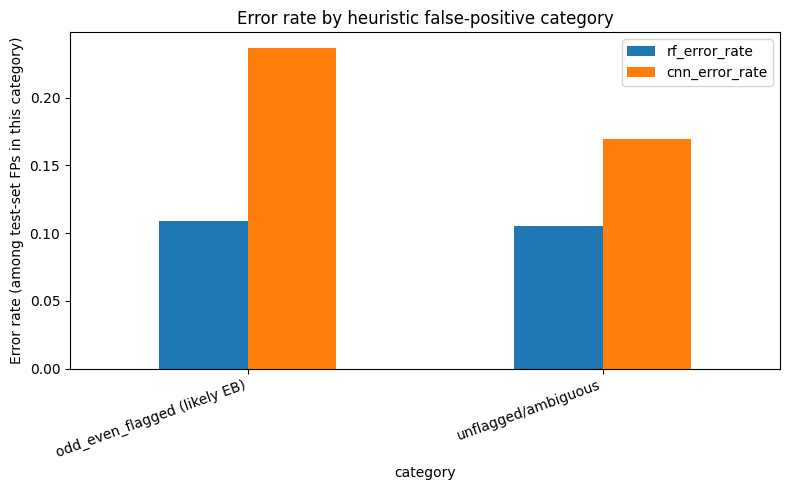

In [ ]:
diag_cols = ['kepid', 'tce_plnt_num', 'av_vf_ntp', 'av_vf_afp', 'tce_bin_oedp_stat']
test_diag = test_df[diag_cols].reset_index(drop=True).copy()
test_diag['y_true'] = y_test
test_diag['rf_pred'] = rf_preds
test_diag['cnn_pred'] = cnn_preds
test_diag['rf_correct'] = (test_diag['rf_pred'] == test_diag['y_true']).astype(int)
test_diag['cnn_correct'] = (test_diag['cnn_pred'] == test_diag['y_true']).astype(int)

fp_mask = test_diag['y_true'] == 0
fp = test_diag[fp_mask].copy()
fp['oedp_abs'] = fp['tce_bin_oedp_stat'].abs()

t_ntl = fp['av_vf_ntp'].quantile(2/3)
t_afp = fp['av_vf_afp'].quantile(2/3)
t_oedp = fp['oedp_abs'].quantile(2/3)

def categorize(row):
    scores = {'not_transit_like': row['av_vf_ntp'] if row['av_vf_ntp'] >= t_ntl else -1,
              'astrophysical_fp': row['av_vf_afp'] if row['av_vf_afp'] >= t_afp else -1,
              'odd_even_flagged (likely EB)': row['oedp_abs'] if row['oedp_abs'] >= t_oedp else -1}
    best = max(scores, key=scores.get)
    return best if scores[best] > -1 else 'unflagged/ambiguous'

fp['category'] = fp.apply(categorize, axis=1)
print(fp['category'].value_counts())

breakdown = fp.groupby('category').agg(
    n=('category', 'size'),
    rf_error_rate=('rf_correct', lambda s: 1 - s.mean()),
    cnn_error_rate=('cnn_correct', lambda s: 1 - s.mean())
).reset_index()
print(breakdown)

breakdown.to_csv(os.path.join(RES_DIR, 'error_mode_breakdown.csv'), index=False)

ax = breakdown.set_index('category')[['rf_error_rate', 'cnn_error_rate']].plot(kind='bar', figsize=(8,5))
plt.ylabel('Error rate (among test-set FPs in this category)')
plt.title('Error rate by heuristic false-positive category')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'error_mode_breakdown.png'), dpi=150)
plt.show()


## 3. Augmentation sweep — five noise levels instead of one

{'alpha': 0.0, 'accuracy': 0.8421828908554573, 'precision': 0.8761609907120743, 'recall': 0.8085714285714286, 'f1': 0.8410104011887073, 'roc_auc': np.float64(0.8924303135888502)}
{'alpha': 0.05, 'accuracy': 0.8215339233038348, 'precision': 0.8778877887788779, 'recall': 0.76, 'f1': 0.8147013782542113, 'roc_auc': np.float64(0.8895731707317074)}
{'alpha': 0.1, 'accuracy': 0.8171091445427728, 'precision': 0.853125, 'recall': 0.78, 'f1': 0.8149253731343283, 'roc_auc': np.float64(0.8909843205574914)}
{'alpha': 0.2, 'accuracy': 0.8185840707964602, 'precision': 0.8795986622073578, 'recall': 0.7514285714285714, 'f1': 0.810477657935285, 'roc_auc': np.float64(0.8876742160278747)}
{'alpha': 0.3, 'accuracy': 0.8244837758112095, 'precision': 0.8737864077669902, 'recall': 0.7714285714285715, 'f1': 0.8194233687405159, 'roc_auc': np.float64(0.8854878048780488)}
{'alpha': 0.5, 'accuracy': 0.8082595870206489, 'precision': 0.8691275167785235, 'recall': 0.74, 'f1': 0.7993827160493827, 'roc_auc': np.float64

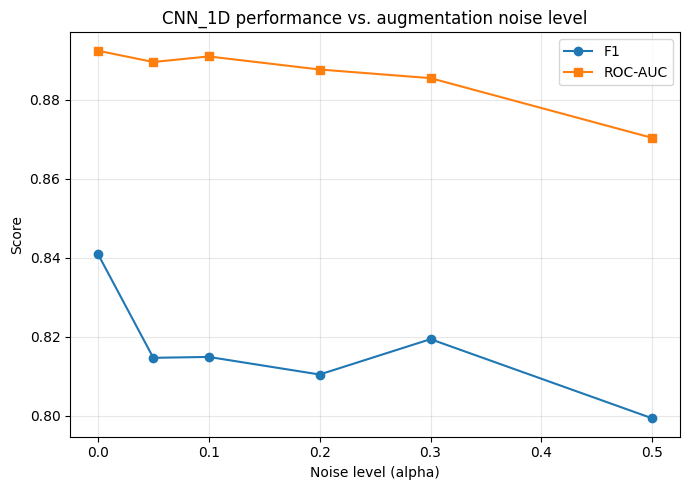

In [ ]:
alphas = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
sweep_rows = []
for a in alphas:
    model, _ = train_cnn(Conv1DClassifier(), idx_train, idx_val, augment_train=(a > 0), alpha=a, seed=SEED)
    yt, probs = eval_cnn(model, idx_test)
    preds = (probs > 0.5).astype(int)
    row = {'alpha': a, 'accuracy': accuracy_score(yt, preds), 'precision': precision_score(yt, preds),
           'recall': recall_score(yt, preds), 'f1': f1_score(yt, preds), 'roc_auc': roc_auc_score(yt, probs)}
    sweep_rows.append(row)
    print(row)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(os.path.join(RES_DIR, 'augmentation_sweep_results.csv'), index=False)

plt.figure(figsize=(7,5))
plt.plot(sweep_df['alpha'], sweep_df['f1'], marker='o', label='F1')
plt.plot(sweep_df['alpha'], sweep_df['roc_auc'], marker='s', label='ROC-AUC')
plt.xlabel('Noise level (alpha)')
plt.ylabel('Score')
plt.title('CNN_1D performance vs. augmentation noise level')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'augmentation_sweep_curve.png'), dpi=150)
plt.show()


## 4. Learning curves — RF_main and CNN_1D vs. training-set size

{'train_frac': 0.1, 'n_train': 316, 'rf_f1': 0.847457627118644, 'rf_auc': np.float64(0.9200522648083623), 'cnn_f1': 0.7769985974754559, 'cnn_auc': np.float64(0.848109756097561)}
{'train_frac': 0.25, 'n_train': 790, 'rf_f1': 0.8771428571428571, 'rf_auc': np.float64(0.9311759581881534), 'cnn_f1': 0.7780821917808219, 'cnn_auc': np.float64(0.8434146341463415)}
{'train_frac': 0.5, 'n_train': 1580, 'rf_f1': 0.8911174785100286, 'rf_auc': np.float64(0.9448606271777004), 'cnn_f1': 0.7850467289719626, 'cnn_auc': np.float64(0.8625261324041811)}
{'train_frac': 0.75, 'n_train': 2370, 'rf_f1': 0.8933143669985776, 'rf_auc': np.float64(0.9472865853658536), 'cnn_f1': 0.8219584569732937, 'cnn_auc': np.float64(0.8796341463414635)}
{'train_frac': 1.0, 'n_train': 3160, 'rf_f1': 0.8968481375358166, 'rf_auc': np.float64(0.9505270034843205), 'cnn_f1': 0.8122137404580153, 'cnn_auc': np.float64(0.892761324041812)}


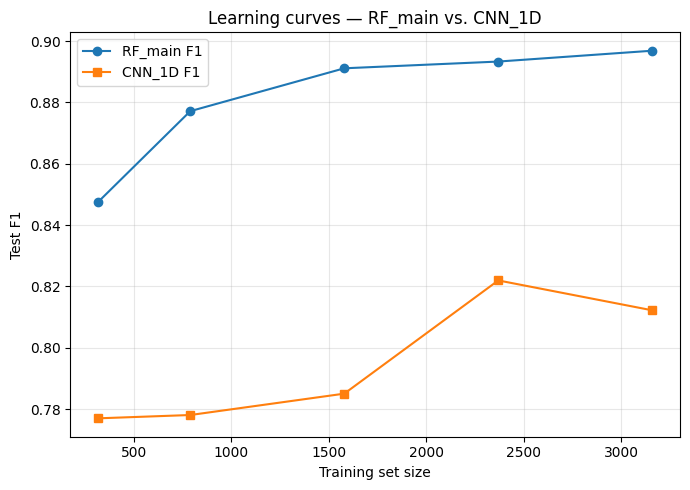

In [ ]:
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
lc_rows = []
y_train_full = train_df['label'].values

for frac in fractions:
    if frac < 1.0:
        sub_idx, _ = train_test_split(idx_train, train_size=frac, random_state=SEED, stratify=y_train_full)
    else:
        sub_idx = idx_train
    sub_df = data.loc[sub_idx]

    # RF_main at this fraction
    X_train = sub_df[RF_FEATURES].values
    X_test = test_df[RF_FEATURES].values
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, sub_df['label'].values)
    rf_p = rf.predict_proba(X_test)[:, 1]
    rf_pred = (rf_p > 0.5).astype(int)

    # CNN_1D at this fraction (same architecture/training protocol)
    cnn_m, _ = train_cnn(Conv1DClassifier(), sub_idx, idx_val, seed=SEED)
    _, cnn_p = eval_cnn(cnn_m, idx_test)
    cnn_pred = (cnn_p > 0.5).astype(int)

    lc_rows.append({'train_frac': frac, 'n_train': len(sub_idx),
                     'rf_f1': f1_score(y_test, rf_pred), 'rf_auc': roc_auc_score(y_test, rf_p),
                     'cnn_f1': f1_score(y_test, cnn_pred), 'cnn_auc': roc_auc_score(y_test, cnn_p)})
    print(lc_rows[-1])

lc_df = pd.DataFrame(lc_rows)
lc_df.to_csv(os.path.join(RES_DIR, 'learning_curves_results.csv'), index=False)

plt.figure(figsize=(7,5))
plt.plot(lc_df['n_train'], lc_df['rf_f1'], marker='o', label='RF_main F1')
plt.plot(lc_df['n_train'], lc_df['cnn_f1'], marker='s', label='CNN_1D F1')
plt.xlabel('Training set size')
plt.ylabel('Test F1')
plt.title('Learning curves — RF_main vs. CNN_1D')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'learning_curves.png'), dpi=150)
plt.show()


## 5. Dual-view (local + global) CNN, small ensemble, cosine LR

**Simplification, stated explicitly:** a true local view (Shallue & Vanderburg 2018) is re-derived from the raw, un-folded flux at finer resolution around the transit alone. We do not have the raw flux at this stage (only the saved 200-point folded arrays), and re-running the multi-day download/preprocessing step is out of scope here. We instead approximate the local view by **cropping the existing global array** to a window around its center (where phase-folding already places the transit) — a strictly weaker version of the true local-view design, but one that tests the same underlying idea (give the model a zoomed, less-diluted look at the transit shape) at no extra data-collection cost.


In [10]:
LOCAL_HALF_WIDTH = 20  # crop [100-20, 100+20) = 40 points around the assumed transit center at index 100
CENTER = flux_matrix.shape[1] // 2

def make_local_view(flux):
    lo, hi = CENTER - LOCAL_HALF_WIDTH, CENTER + LOCAL_HALF_WIDTH
    return flux[lo:hi]

class DualViewDataset(Dataset):
    def __init__(self, indices, augment=False, alpha=0.3):
        self.indices = indices; self.augment = augment; self.alpha = alpha
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        flux = flux_matrix[idx].copy()
        if self.augment:
            noise_std = self.alpha * flux.std()
            flux = flux + np.random.normal(0, noise_std, size=flux.shape).astype(np.float32)
        local = make_local_view(flux)
        return (torch.tensor(flux).unsqueeze(0), torch.tensor(local).unsqueeze(0), torch.tensor(labels_all[idx]))

class DualViewClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def branch():
            return nn.Sequential(
                nn.Conv1d(1, 8, 5, padding=2), nn.BatchNorm1d(8), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout),
                nn.Conv1d(8, 16, 5, padding=2), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout),
            )
        self.global_branch = branch()
        self.local_branch = branch()
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))
    def forward(self, x_global, x_local):
        g = self.gap(self.global_branch(x_global)).squeeze(-1)
        l = self.gap(self.local_branch(x_local)).squeeze(-1)
        return self.head(torch.cat([g, l], dim=1)).squeeze(-1)

_tmp = DualViewClassifier()
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"DualViewClassifier trainable parameters: {n_params:,}")
del _tmp

def train_dual(model, train_idx, val_idx, n_epochs=60, patience=8, lr=1e-3, weight_decay=1e-4, seed=SEED):
    torch.manual_seed(seed)
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    train_loader = DataLoader(DualViewDataset(train_idx), batch_size=64, shuffle=True)
    val_loader = DataLoader(DualViewDataset(val_idx), batch_size=64, shuffle=False)

    best_val_loss, best_state, no_improve = float('inf'), None, 0
    for epoch in range(n_epochs):
        model.train()
        for xg, xl, yb in train_loader:
            xg, xl, yb = xg.to(device), xl.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xg, xl), yb)
            loss.backward(); optimizer.step()
        scheduler.step()
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xg, xl, yb in val_loader:
                xg, xl, yb = xg.to(device), xl.to(device), yb.to(device)
                val_losses.append(criterion(model(xg, xl), yb).item())
        val_loss = np.mean(val_losses)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model

def eval_dual(model, indices):
    loader = DataLoader(DualViewDataset(indices), batch_size=64, shuffle=False)
    probs, labels = [], []
    with torch.no_grad():
        for xg, xl, yb in loader:
            xg, xl = xg.to(device), xl.to(device)
            probs.extend(torch.sigmoid(model(xg, xl)).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(probs)

# Single dual-view model
dual_model = train_dual(DualViewClassifier(), idx_train, idx_val, seed=SEED)
yt, dual_probs = eval_dual(dual_model, idx_test)
dual_preds = (dual_probs > 0.5).astype(int)
print(f"DualView (single): acc={accuracy_score(yt, dual_preds):.4f} f1={f1_score(yt, dual_preds):.4f} auc={roc_auc_score(yt, dual_probs):.4f}")

# Ensemble of 5 dual-view models, different seeds, same data split
ensemble_probs = []
for seed in [42, 43, 44, 45, 46]:
    m = train_dual(DualViewClassifier(), idx_train, idx_val, seed=seed)
    _, p = eval_dual(m, idx_test)
    ensemble_probs.append(p)
ensemble_probs = np.mean(ensemble_probs, axis=0)
ensemble_preds = (ensemble_probs > 0.5).astype(int)
print(f"DualView (5-model ensemble): acc={accuracy_score(yt, ensemble_preds):.4f} f1={f1_score(yt, ensemble_preds):.4f} auc={roc_auc_score(yt, ensemble_probs):.4f}")


DualViewClassifier trainable parameters: 2,049
DualView (single): acc=0.8363 f1=0.8356 auc=0.8950
DualView (5-model ensemble): acc=0.8348 f1=0.8293 auc=0.8950


In [ ]:
comparison = pd.DataFrame([
    {'model': 'CNN_1D (global-only, original)', 'accuracy': accuracy_score(y_test, cnn_preds), 'f1': f1_score(y_test, cnn_preds), 'roc_auc': roc_auc_score(y_test, cnn_probs), 'brier': brier_score_loss(y_test, cnn_probs)},
    {'model': 'CNN_dualview (single)', 'accuracy': accuracy_score(yt, dual_preds), 'f1': f1_score(yt, dual_preds), 'roc_auc': roc_auc_score(yt, dual_probs), 'brier': brier_score_loss(yt, dual_probs)},
    {'model': 'CNN_dualview (5-ensemble)', 'accuracy': accuracy_score(yt, ensemble_preds), 'f1': f1_score(yt, ensemble_preds), 'roc_auc': roc_auc_score(yt, ensemble_probs), 'brier': brier_score_loss(yt, ensemble_probs)},
    {'model': 'RF_main (reference)', 'accuracy': accuracy_score(y_test, rf_preds), 'f1': f1_score(y_test, rf_preds), 'roc_auc': roc_auc_score(y_test, rf_probs), 'brier': brier_score_loss(y_test, rf_probs)},
])
print(comparison)
comparison.to_csv(os.path.join(RES_DIR, 'cnn_improvement_comparison.csv'), index=False)


                            model  accuracy        f1   roc_auc     brier
0  CNN_1D (global-only, original)  0.815634  0.821683  0.883711  0.137646
1           CNN_dualview (single)  0.831858  0.826748  0.895801  0.126078
2       CNN_dualview (5-ensemble)  0.836283  0.830534  0.894922  0.126928
3             RF_main (reference)  0.893805  0.896848  0.950527  0.082737


## 6. Save everything needed to rebuild the paper's new section

In [ ]:
print("Saved to Drive:")
print(" -", os.path.join(RES_DIR, 'error_mode_breakdown.csv'))
print(" -", os.path.join(FIG_DIR, 'error_mode_breakdown.png'))
print(" -", os.path.join(RES_DIR, 'augmentation_sweep_results.csv'))
print(" -", os.path.join(FIG_DIR, 'augmentation_sweep_curve.png'))
print(" -", os.path.join(RES_DIR, 'learning_curves_results.csv'))
print(" -", os.path.join(FIG_DIR, 'learning_curves.png'))
print(" -", os.path.join(RES_DIR, 'cnn_improvement_comparison.csv'))
print("Please download/upload back: the 3 CSVs above + 2 PNGs above, so the paper can be updated with real numbers.")


Saved to Drive:
 - /content/drive/MyDrive/SADA/results/error_mode_breakdown.csv
 - /content/drive/MyDrive/SADA/figures/error_mode_breakdown.png
 - /content/drive/MyDrive/SADA/results/augmentation_sweep_results.csv
 - /content/drive/MyDrive/SADA/figures/augmentation_sweep_curve.png
 - /content/drive/MyDrive/SADA/results/learning_curves_results.csv
 - /content/drive/MyDrive/SADA/figures/learning_curves.png
 - /content/drive/MyDrive/SADA/results/cnn_improvement_comparison.csv
Please download/upload back: the 3 CSVs above + 2 PNGs above, so the paper can be updated with real numbers.


In [7]:
pip install joblib

In [8]:
import joblib
import os

# Define the path to save the model
RF_MODEL_PATH = os.path.join(RES_DIR, 'rf_main.joblib')

# Save the trained rf_main model
joblib.dump(rf_main, RF_MODEL_PATH)
print(f"RF_main model saved to: {RF_MODEL_PATH}")

RF_main model saved to: /content/drive/MyDrive/SADA/results/rf_main.joblib


In [11]:
DUAL_MODEL_PATH = os.path.join(RES_DIR, 'dual_view_single_model.pth')
torch.save(dual_model.state_dict(), DUAL_MODEL_PATH)
print(f"DualView (single) model saved to: {DUAL_MODEL_PATH}")

DualView (single) model saved to: /content/drive/MyDrive/SADA/results/dual_view_single_model.pth
